In [62]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [63]:
dataset = pd.read_csv("D:\chatbot\dataset\Phishing_Legitimate_full.csv")
dataset.head(4)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20400\825382338.py:1: SyntaxWarning: invalid escape sequence '\c'
  dataset = pd.read_csv("D:\chatbot\dataset\Phishing_Legitimate_full.csv")


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1


In [64]:
dataset['CLASS_LABEL'].unique()


array([1, 0], dtype=int64)

In [65]:
dataset.describe()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.445100,0.586800,3.300300,70.264100,1.818000,0.138900,0.000300,0.013100,0.32320,...,0.339600,0.03220,0.030400,0.956600,0.020200,0.353300,0.793200,0.173400,0.314100,0.500000
std,2886.89568,1.346836,0.751214,1.863241,33.369877,3.106258,0.545744,0.017319,0.113709,1.11466,...,0.473597,0.17654,0.171694,0.248037,0.820036,0.888908,0.521019,0.755771,0.897843,0.500025
min,1.00000,1.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,2500.75000,2.000000,0.000000,2.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,1.000000,-1.000000,-1.000000,1.000000,0.000000,-1.000000,0.000000
50%,5000.50000,2.000000,1.000000,3.000000,62.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.500000
75%,7500.25000,3.000000,1.000000,4.000000,84.000000,2.000000,0.000000,0.000000,0.000000,0.00000,...,1.000000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,10000.00000,21.000000,14.000000,18.000000,253.000000,55.000000,9.000000,1.000000,1.000000,18.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [80]:
# dataset['UrlLengthScaled'] = (dataset['UrlLength'] - dataset['UrlLength'].min()) / (dataset['UrlLength'].max() - dataset['UrlLength'].min())


In [67]:
X = dataset.drop(columns=["id","UrlLength","CLASS_LABEL"])
y = dataset['CLASS_LABEL']
print(X.shape)
print(y.shape)

(10000, 47)
(10000,)


In [68]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

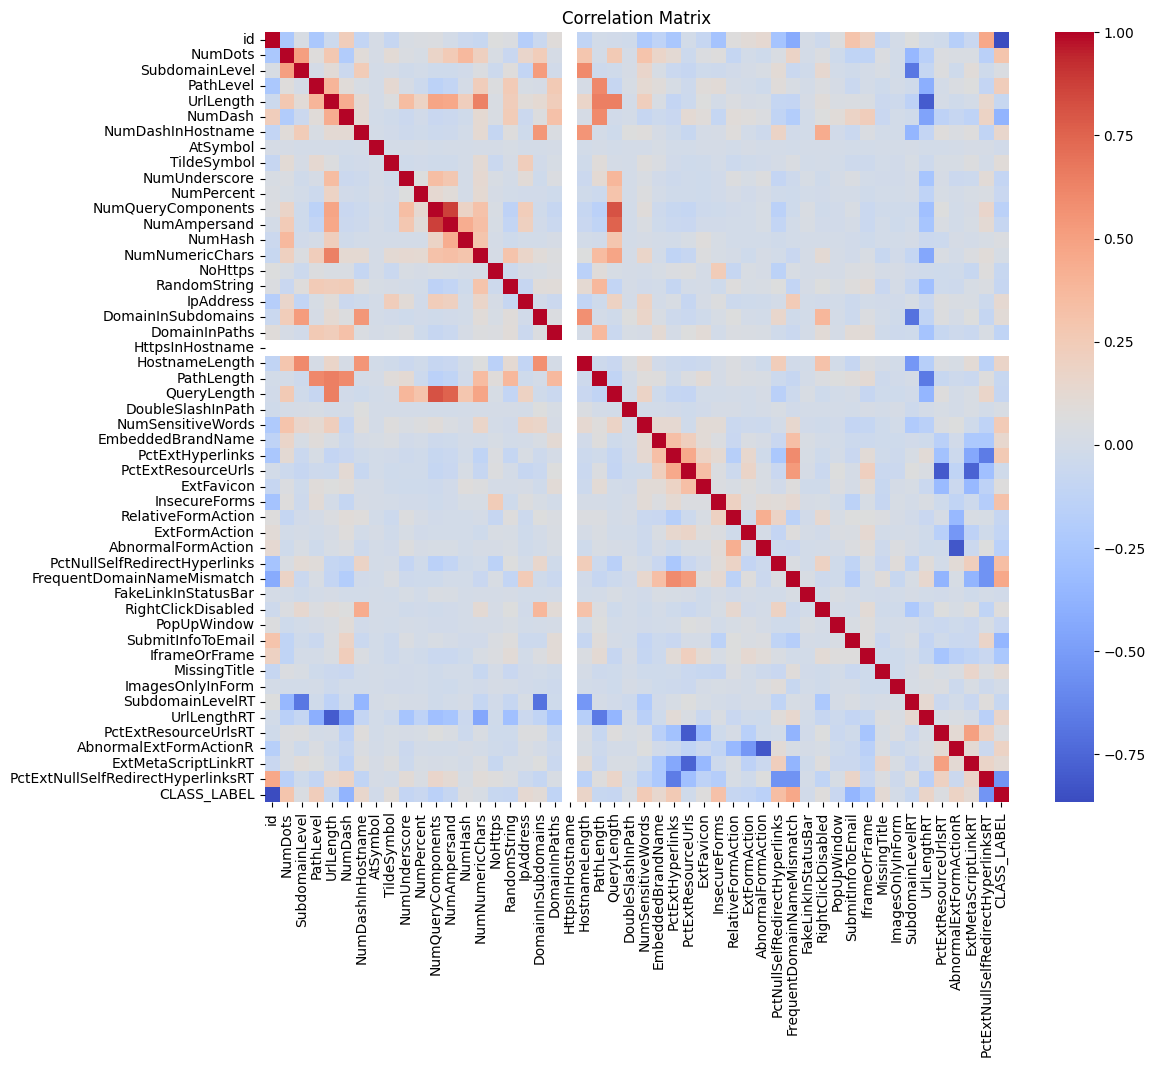

In [69]:
plt.figure(figsize=(12, 10))
sns.heatmap(dataset.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()


In [70]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,stratify=y)
print(x_train.shape)
print(y_train.shape)

(8000, 47)
(8000,)


In [71]:
from sklearn.linear_model import LogisticRegression

Logi_model = LogisticRegression()
Logi_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
# Make predictions
y_pred = Logi_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["benign", "malicious"]))


Accuracy: 0.946
              precision    recall  f1-score   support

      benign       0.95      0.94      0.95      1000
   malicious       0.95      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [73]:
from sklearn.svm import SVC

svc_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svc_model.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [74]:
# Make predictions
y_pred = svc_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["benign", "malicious"]))


Accuracy: 0.9645
              precision    recall  f1-score   support

      benign       0.96      0.96      0.96      1000
   malicious       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



In [ ]:
import re
from urllib.parse import urlparse

def extract_features_from_url(url):
    parsed = urlparse(url)
    hostname = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""

    features = {
        "NumDots": url.count('.'),
        "SubdomainLevel": hostname.count('.') - 1 if hostname else 0,
        "PathLevel": path.count('/'),
        "NumDash": url.count('-'),
        "NumDashInHostname": hostname.count('-'),
        "AtSymbol": int("@" in url),
        "TildeSymbol": int("~" in url),
        "NumUnderscore": url.count('_'),
        "NumPercent": url.count('%'),
        "NumQueryComponents": query.count('='),
        "NumAmpersand": url.count('&'),
        "NumHash": url.count('#'),
        "NumNumericChars": len(re.findall(r'\d', url)),
        "NoHttps": int(not url.startswith("https")),
        "RandomString": 0,  # placeholder – needs your logic
        "IpAddress": int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', hostname))),
        "DomainInSubdomains": 0,  # placeholder
        "DomainInPaths": 0,  # placeholder
        "HttpsInHostname": int("https" in hostname),
        "HostnameLength": len(hostname),
        "PathLength": len(path),
        "QueryLength": len(query),
        "DoubleSlashInPath": int("//" in path),
        "NumSensitiveWords": sum(int(word in url.lower()) for word in ["secure", "login", "verify", "update","search","page","query"]),
        "EmbeddedBrandName": 0,  # placeholder
        "PctExtHyperlinks": 0,  # assume 0 for URL-only input
        "PctExtResourceUrls": 0,
        "ExtFavicon": 0,
        "InsecureForms": 0,
        "RelativeFormAction": 0,
        "ExtFormAction": 0,
        "AbnormalFormAction": 0,
        "PctNullSelfRedirectHyperlinks": 0,
        "FrequentDomainNameMismatch": 0,
        "FakeLinkInStatusBar": 0,
        "RightClickDisabled": 0,
        "PopUpWindow": 0,
        "SubmitInfoToEmail": 0,
        "IframeOrFrame": 0,
        "MissingTitle": 0,
        "ImagesOnlyInForm": 0,
        "SubdomainLevelRT": 0,
        "UrlLengthRT": 0,
        "PctExtResourceUrlsRT": 0,
        "AbnormalExtFormActionR": 0,
        "ExtMetaScriptLinkRT": 0,
        "PctExtNullSelfRedirectHyperlinksRT": 0,
    }

    return pd.DataFrame([features])


In [81]:
trusted_domains = ["google.com", "kaggle.com", "github.com", "wikipedia.org", "chatgpt.com"]

In [94]:
test_url = "https://fakebook.com"
test_features = extract_features_from_url(test_url)
test_features = test_features[X.columns]
test_scaled = scaler.transform(test_features)

# Predict using trained SVM
prediction = svc_model.predict(test_scaled)
proba = svc_model.decision_function(test_scaled)

# Result
label = "malicious" if prediction[0] == 1 else "benign"
print(f"🔍 The URL is predicted to be: {label} (score: {proba[0]:.3f})")


🔍 The URL is predicted to be: benign (score: -0.151)


['google.com', 'kaggle.com', 'github.com', 'wikipedia.org', 'chatgpt.com']


In [ ]:
trusted_domains = ["google.com", "kaggle.com", "github.com", "wikipedia.org", "chatgpt.com"]

def is_trusted_domain(url):
    for domain in trusted_domains:
        if domain in url:
            return 1
    return 0

# Test URLs
test_urls = [
    "https://www.google.com/search?q=java+rmi",
    "https://chatgpt.com/c/6878e398-8908-8006-80e4-01b4162808cc",
    "http://suspicious-website.phishingsite.net/login",
    "https://kaggle.com/datasets/shashwatwork/phishing-dataset-for-machine-learning/code"
]


   
